# Modern Portfolio Theory: Mean Variance Optimization

### Cleaning the data

In [1]:
#Project Dependencies: 
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import cvxopt as opt
from cvxopt import blas, solvers

import dataframe_image as dfi




In [2]:
# Loading the dataset:
sp500 = pd.read_csv('all_stocks_5yr.csv')
sp500.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [3]:
sp500.value_counts().isna()
rows_with_nulls = sp500.loc[sp500.isna().any(axis=1)]
rows_with_nulls

,date,open,high,low,close,volume,Name
82949,2017-07-26,NaN,NaN,NaN,69.0842,3,BHF
165734,2015-07-17,NaN,88.76,88.24,88.7200,2056819,DHR
165857,2016-01-12,NaN,NaN,NaN,88.5500,0,DHR
205076,2015-07-17,NaN,48.49,47.85,47.9200,1246786,ES
239832,2016-07-01,NaN,NaN,NaN,49.5400,0,FTV
434379,2015-07-17,NaN,47.31,46.83,46.9900,1229513,O
434502,2016-01-12,NaN,NaN,NaN,52.4300,0,O
478594,2015-06-09,NaN,NaN,NaN,526.0900,12135,REGN
558213,2016-04-07,NaN,NaN,NaN,41.5600,0,UA
581906,2015-05-12,NaN,NaN,NaN,124.0800,569747,VRTX


Some values contain missing data for 'open', 'high' and 'low', but there are no missing values for the 'close' column. Since the calculations for analyzing risk and return rely on the close data it is safe to ignore these null values as they will have no impact on portfolio optimization. 

In [4]:
sp500.dtypes

date          str
open      float64
high      float64
low       float64
close     float64
volume      int64
Name          str
dtype: object

In [5]:
sp500.columns = sp500.columns.str.title()
sp500

,Date,Open,High,Low,Close,Volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL
...,...,...,...,...,...,...,...
619035,2018-02-01,76.84,78.27,76.69,77.82,2982259,ZTS
619036,2018-02-02,77.53,78.12,76.73,76.78,2595187,ZTS
619037,2018-02-05,76.64,76.92,73.18,73.83,2962031,ZTS
619038,2018-02-06,72.74,74.56,72.13,73.27,4924323,ZTS


The 'date' column is currently stored as the datatype string, so I will convert it to datetime.

In [6]:
sp500['Date'] = pd.to_datetime(sp500['Date'])
sp500.dtypes

Date      datetime64[us]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
Name                 str
dtype: object

### Pivoting the data

For portfolio analyses, we want to calculate returns, correlations and metrics across multiple stocks. At present, the dataset is in long format, meaning that each row represents one stock on each date. 

In order to perform calculations efficiently, we must convert the table to wide format by using .pivot(). This means that each column will represent a single stock, and each row will represent a single date. This will make it far easier to calculate daily returns, compute correlation and covariance and perform Mean Variance Optimization so that we can create the efficient frontier. 

In [7]:
prices = pd.pivot(sp500, index = 'Date', columns='Name', values = 'Close')
prices.head()

Name,A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,...,XL,XLNX,XOM,XRAY,XRX,XYL,YUM,ZBH,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2013-02-08,45.08,14.75,78.90,67.8542,36.25,46.89,34.41,73.31,39.12,45.70,...,28.24,37.51,88.61,42.87,31.84,27.09,65.30,75.85,24.14,33.05
2013-02-11,44.60,14.46,78.39,68.5614,35.85,46.76,34.26,73.07,38.64,46.08,...,28.31,37.46,88.28,42.84,31.96,27.46,64.55,75.65,24.21,33.26
2013-02-12,44.62,14.27,78.60,66.8428,35.42,46.96,34.30,73.37,38.89,46.27,...,28.41,37.58,88.46,42.87,31.84,27.95,64.75,75.44,24.49,33.74
2013-02-13,44.75,14.66,78.97,66.7156,35.27,46.64,34.46,73.56,38.81,46.26,...,28.42,37.80,88.67,43.08,32.00,28.26,64.41,76.00,24.74,33.55
2013-02-14,44.58,13.99,78.84,66.6556,36.57,46.77,34.70,73.13,38.61,46.54,...,28.22,38.44,88.52,42.91,32.12,28.47,63.89,76.34,24.63,33.27


### Selecting Stocks

In [8]:
solvers.options['show_progress'] = False
returns = prices.pct_change().dropna()
returns_mean = returns.mean()
volatility = returns.std()
correlation_matrix = returns.corr()
print(correlation_matrix)


Name         A       AAL       AAP      AAPL      ABBV       ABC       ABT  \
Name                                                                         
A     1.000000  0.318771  0.460915  0.449194  0.471821  0.588136  0.558611   
AAL   0.318771  1.000000  0.308245  0.598168  0.048245  0.191883 -0.017178   
AAP   0.460915  0.308245  1.000000  0.502703  0.414300  0.399101  0.522497   
AAPL  0.449194  0.598168  0.502703  1.000000  0.231405  0.262580  0.240539   
ABBV  0.471821  0.048245  0.414300  0.231405  1.000000  0.440349  0.355300   
...        ...       ...       ...       ...       ...       ...       ...   
XYL   0.420828  0.073052  0.236101 -0.003638  0.507228  0.373597  0.419124   
YUM   0.678198  0.435096  0.531693  0.472241  0.424861  0.463384  0.432812   
ZBH   0.370001  0.075644  0.140804  0.160827  0.247024  0.467750  0.421852   
ZION  0.546767  0.491773  0.406436  0.363504  0.447226  0.418046  0.345824   
ZTS   0.644180  0.065838  0.401499  0.221463  0.536585  0.666403

In [ ]:
#Create df for the interactive scatter plot
riskreturn_plot = pd.DataFrame({
    'Stock Name': returns_mean.index,
    'Mean Return': returns_mean.values,
    'Volatility': volatility.values
})
fig = px.scatter(
    riskreturn_plot,
    x='Volatility',
    y='Mean Return',
    text='Stock Name',      
    title='Interactive Risk vs Return Scatter',
    labels={'Volatility': 'Volatility (Std of Returns)', 'Mean Return': 'Mean Daily Return'},
    width=800,
    height=500
)

fig.update_traces(textposition='top center', marker=dict(size=10))
fig.show()


RuntimeError: 
Image export requires the Kaleido package, v1.0.0 or greater,
which can be installed using pip:

    $ pip install --upgrade "kaleido>=1"


In [10]:
selected = ['DXC', 'STZ', 'NVDA', 'INCY', 'NOC', 'DAL']
selected_returns = prices[selected].pct_change()
selected_corr = selected_returns.corr()
selected_returns_mean = selected_returns.mean()





The stocks that I selected for the portfolio show a low to moderate correlation, ranging from between 0.13 and 0.33. This implies diversification benefits to the portfolio as none of the stocks display strong co-movement so will hopefully not be affected by the same market influences. 

The stocks that I have selected are:

- **DXC (DXC Technology)**  
  - Sector: Information Technology  
  - Industry: IT Services / Consulting  

- **STZ (Constellation Brands)**  
  - Sector: Consumer Staples  
  - Industry: Beverages (Alcoholic)  

- **NVDA (NVIDIA)**  
  - Sector: Information Technology  
  - Industry: Semiconductors  

- **INCY (Incyte)**  
  - Sector: Healthcare  
  - Industry: Biotechnology  

- **NOC (Northrop Grumman)**  
  - Sector: Industrials  
  - Industry: Aerospace & Defense  

- **DAL (Delta Air Lines)**  
  - Sector: Industrials  
  - Industry: Airlines  

In [11]:
selected_corr

Name,DXC,STZ,NVDA,INCY,NOC,DAL
Name,,,,,,
DXC,1.000000,0.246590,0.298778,0.134130,0.212965,0.133572
STZ,0.246590,1.000000,0.184034,0.204346,0.223080,0.154337
NVDA,0.298778,0.184034,1.000000,0.168639,0.263347,0.266477
INCY,0.134130,0.204346,0.168639,1.000000,0.230925,0.285703
NOC,0.212965,0.223080,0.263347,0.230925,1.000000,0.326333
DAL,0.133572,0.154337,0.266477,0.285703,0.326333,1.000000


Now we will create the covariance matrix so that we can view the optimal frontier.

In [12]:
selected_cov = selected_returns.cov()
annual_returns = selected_returns_mean*252
annual_cov = selected_cov*252

In [13]:
## Function to generate portfolios 
def return_portfolios(expected_returns, cov_matrix):
  np.random.seed(1)
  port_returns = []
  port_volatility = []
  stock_weights = []
    
  selected = (expected_returns.axes)[0]
    
  num_assets = len(selected) 
  num_portfolios = 10000
    
  for single_portfolio in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    returns = np.dot(weights, expected_returns)
    volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    port_returns.append(returns)
    port_volatility.append(volatility)
    stock_weights.append(weights)
    
    portfolio = {'Returns': port_returns,
                 'Volatility': port_volatility}
    
  for counter,symbol in enumerate(selected):
    portfolio[symbol +' Weight'] = [Weight[counter] for Weight in stock_weights]
    
  df = pd.DataFrame(portfolio)
    
  column_order = ['Returns', 'Volatility'] + [stock+' Weight' for stock in selected]
    
  df = df[column_order]
   
  return df

In [14]:
simulated_portfolios = return_portfolios(annual_returns, annual_cov)
simulated_portfolios.head()
simulated_returns = simulated_portfolios['Returns']
simulated_volatility = simulated_portfolios['Volatility']


In [ ]:
def optimal_portfolio(expected_returns, cov_matrix):
    n = len(expected_returns)
    returns = np.array(expected_returns)  # annualized expected returns

    # Convert covariance matrix to numpy array and regularize
    S = opt.matrix(cov_matrix.values + 1e-6*np.eye(n))  # small diagonal added
    pbar = opt.matrix(returns)

    # Constraint matrices
    G = -opt.matrix(np.eye(n))
    h = opt.matrix(0.0, (n,1))
    A = opt.matrix(1.0, (1,n))
    b = opt.matrix(1.0)

    # Efficient frontier
    N = 100
    mus = [10**(5.0 * t/N - 1.0) for t in range(N)]
    portfolios = [solvers.qp(mu*S, -pbar, G, h, A, b)['x'] for mu in mus]

    # Risks and returns
    rets = [blas.dot(pbar, x) for x in portfolios]
    risks = [np.sqrt(blas.dot(x, S*x)) for x in portfolios]

    # Optimal weights (min risk for return)
    m1 = np.polyfit(rets, risks, 2)
    x1 = np.sqrt(m1[2] / m1[0])
    wt = solvers.qp(opt.matrix(x1 * S), -pbar, G, h, A, b)['x']

    return np.asarray(wt), rets, risks



In [16]:
weights, returns, risks = optimal_portfolio(annual_returns, annual_cov)

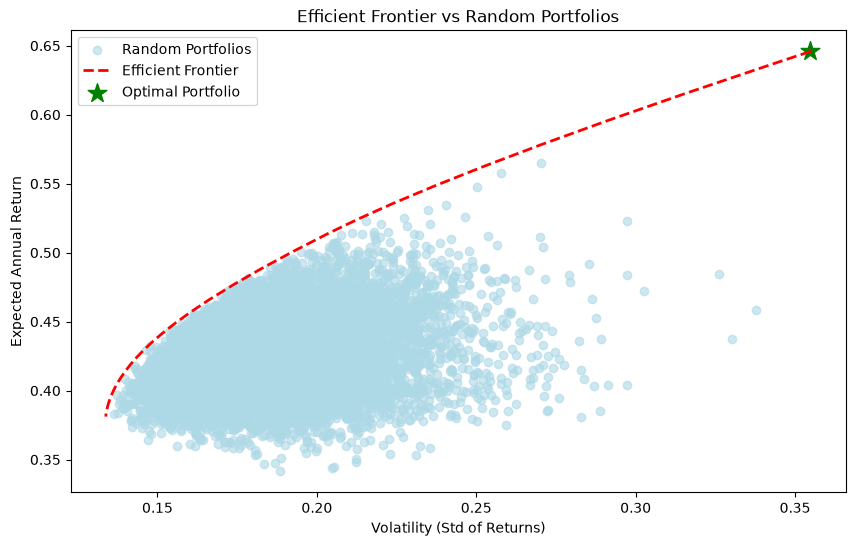

In [ ]:
# Plot simulated portfolios
plt.figure(figsize=(10,6))
plt.scatter(simulated_volatility, simulated_returns, c='lightblue', label='Random Portfolios', alpha=0.6)

# Plot Efficient Frontier
plt.plot(risks, returns, 'r--', linewidth=2, label='Efficient Frontier')

# Highlight optimal portfolio
optimal_vol = np.sqrt(np.dot(weights.T, np.dot(annual_cov.values, weights)))
weights = weights.flatten()
optimal_ret = np.dot(weights, annual_returns.values)
plt.scatter(optimal_vol, optimal_ret, c='green', marker='*', s=200, label='Optimal Portfolio')

plt.xlabel('Volatility (Std of Returns)')
plt.ylabel('Expected Annual Return')
plt.title('Efficient Frontier vs Random Portfolios')
plt.legend()

plt.show()

In [18]:
weights = weights.flatten()

weights_df = pd.DataFrame({
    'Stock': selected,
    'Weight': weights
})

weights_df['Weight'] = weights_df['Weight'] * 100

print(np.sum(weights_df['Weight']))
weights_df

100.0


,Stock,Weight
0,DXC,4.992095e-07
1,STZ,7.528888e-07
2,NVDA,1.000000e+02
3,INCY,1.077763e-06
4,NOC,7.913440e-07
5,DAL,8.501085e-07


Currently the portfolio returns do not have a percent limit for each stock, which is leading to NVDA dominating the weighting due to its historically high returns. The unconstrained optimsation resulted in an allocation that heavily favoured `NVIDIA` due to its historically high returns. While this is mathematically valid, it would expose the investor to risk given that the majority of the optimised portfolio would be made of a single stock. A maximum weight of `50%` was therefore introduced to encourage diversification. 

At present, the only constraint in the `optimal_portfolio` function is that the weights must sum to 1 and be ≧ 0. To fix the problem of `NVDA` dominating the weighting, I will add a max-weight constraint of 0.5

In [19]:
def optimal_portfolio_constrained(expected_returns, cov_matrix, min_weight=0.05, max_weight=0.5):
    n = len(expected_returns)
    returns = np.array(expected_returns)

    # Covariance matrix (regularised)
    S = opt.matrix(cov_matrix.values + 1e-6 * np.eye(n))
    pbar = opt.matrix(returns)

    # ---------------- CONSTRAINTS ----------------
    # w >= min_weight AND w <= max_weight
    G = opt.matrix(np.vstack([
        -np.eye(n),   # w >= 0 (we'll adjust via bounds below)
         np.eye(n)    # w <= max_weight
    ]))

    h = opt.matrix(np.hstack([
        -np.ones(n) * min_weight,   # converts w >= min_weight into -w <= -min
         np.ones(n) * max_weight    # w <= max_weight
    ]))

    # sum of weights = 1
    A = opt.matrix(1.0, (1, n))
    b = opt.matrix(1.0)

    # ---------------- EFFICIENT FRONTIER ----------------
    N = 100
    mus = [10**(5.0 * t/N - 1.0) for t in range(N)]
    portfolios = [solvers.qp(mu * S, -pbar, G, h, A, b)['x'] for mu in mus]

# returns + risks + weights
    rets = [blas.dot(pbar, x) for x in portfolios]
    risks = [np.sqrt(blas.dot(x, S * x)) for x in portfolios]
    weights_frontier = [np.asarray(x).flatten() for x in portfolios]

    # optimal point (quadratic fit approximation)
    m1 = np.polyfit(rets, risks, 2)
    x1 = np.sqrt(m1[2] / m1[0])
    wt = solvers.qp(opt.matrix(x1 * S), -pbar, G, h, A, b)['x']

    return np.asarray(wt), rets, risks , weights_frontier

In [20]:
weights_c, returns_c, risks_c, weights_frontier = optimal_portfolio_constrained(
    annual_returns,
    annual_cov,
    max_weight=0.5
)

In [21]:
weights_constrained_df = pd.DataFrame({
    'Stock': selected,
    'Weight (%)': weights_c.flatten() * 100
})
weights_constrained_df['Weight (%)'].sum()
weights_constrained_df

,Stock,Weight (%)
0,DXC,29.999827
1,STZ,5.000043
2,NVDA,49.999998
3,INCY,5.000125
4,NOC,5.000004
5,DAL,5.000003


### Portfolio Selection For Different Risk Profiles

After generating the efficient frontier using mean-variance optimisation, the model produces a range of possible portfolios, each representing a different trade-off between expected return and risk (volatility).

Instead of presenting a single “optimal” portfolio, we now select representative portfolios from the efficient frontier to reflect different investor risk preferences.

These portfolios are chosen based on their position along the risk–return spectrum:

* Low-risk portfolio: selected from portfolios with the lowest volatility
* Medium-risk portfolio: selected from a balanced point along the efficient frontier
* High-risk portfolio: selected from portfolios with the highest expected return

This approach allows us to translate the mathematical optimisation results into practical investment options that align with different client objectives.

Each portfolio will be evaluated in terms of:

* Expected annual return
* Annual volatility (risk)
* Asset allocation (weights across selected stocks)

These results will be used to provide clear investment recommendations tailored to varying levels of risk tolerance.



In [22]:
# LOW RISK → minimum volatility

i_low = np.argmin(risks_c)

# HIGH RISK → maximum expected return

i_high = np.argmax(returns_c)

# MEDIUM RISK → middle of the efficient frontier

i_mid = len(risks_c) // 2

low_weights = weights_frontier[i_low]
medium_weights = weights_frontier[i_mid]
high_weights = weights_frontier[i_high]

In [23]:
portfolio_weights = pd.DataFrame({
    'Stock': selected,
    'Low Risk (%)': low_weights * 100,
    'Medium Risk (%)': medium_weights * 100,
    'High Risk (%)': high_weights * 100
})

portfolio_weights

,Stock,Low Risk (%),Medium Risk (%),High Risk (%)
0,DXC,32.908373,37.051585,29.999907
1,STZ,12.073570,13.830982,5.000006
2,NVDA,5.000000,5.001950,49.999997
3,INCY,5.000000,5.000000,5.000079
4,NOC,40.018048,34.115483,5.000006
5,DAL,5.000010,5.000000,5.000005


In [24]:


portfolio_summary = {

    "Low Risk": {

        "Return": returns_c[i_low],

        "Risk": risks_c[i_low]

    },

    "Medium Risk": {

        "Return": returns_c[i_mid],

        "Risk": risks_c[i_mid]

    },

    "High Risk": {

        "Return": returns_c[i_high],

        "Risk": risks_c[i_high]

    }

}

portfolio_summary

{'Low Risk': {'Return': 0.3962296546063562,
  'Risk': np.float64(0.13759110701201868)},
 'Medium Risk': {'Return': 0.4010358759344308,
  'Risk': np.float64(0.13814482168599831)},
 'High Risk': {'Return': 0.5253957182813948,
  'Risk': np.float64(0.22234633395486508)}}

In [25]:
portfolio_summary_df = pd.DataFrame({
    'Portfolio': ['Low Risk', 'Medium Risk', 'High Risk'],
    'Expected Annual Return (%)': [
        returns_c[i_low] * 100,
        returns_c[i_mid] * 100,
        returns_c[i_high] * 100
    ],
    'Annual Volatility (%)': [
        risks_c[i_low] * 100,
        risks_c[i_mid] * 100,
        risks_c[i_high] * 100
    ]
})

portfolio_summary_df

,Portfolio,Expected Annual Return (%),Annual Volatility (%)
0,Low Risk,39.622965,13.759111
1,Medium Risk,40.103588,13.814482
2,High Risk,52.539572,22.234633


As the tolerance for risk increases, the portfolio shifts towards stocks that have a higher historical return. The `high risk` portfolio allocates the maximum `50%` to `NVDA`, while the lower risk portfolio places greater weight on `NOC` and `DXC`. This exemplifies how the efficient frontier can be used to create portfolios with different characteristics of risk and return. 

### Conclusion

This analysis shows how historical stock returns, volatility and correlation can be used to construct diversified portfolios using mean-variance optimisation. Six stocks with relatively low correlation were selected and used to generate an efficient frontier. 

A maximum portfolio weight of 50% per stock was introduced to stop the optimisation from becoming concentrated in a single stock. Three representative portfolios were then selected to demonstrate different levels of risk, with the low risk, medium risk and high risk portfolios having different trade-offs between return and volatility.

These results are based on historical data and therefore shouldn't be interpreted as predictions of future performance. The expected returns and portfolio allocations are dependent on the historical period used and the assumptions of mean-variance optimisation.